In [53]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

In [54]:
yihan = pd.read_csv("../data/processed/clean_sg_part_a_yihan.csv")
junhui = pd.read_csv("../data/processed/clean_sg_part_b_junhui.csv")

print("Yihan shape:", yihan.shape)
print("Junhui shape:", junhui.shape)

Yihan shape: (2012, 5)
Junhui shape: (2012, 7)


In [55]:
sg = pd.merge(
    yihan,
    junhui,
    on="D_INTERVIEW",
    how="inner"
)

print("Merged shape:", sg.shape)
sg.head()

Merged shape: (2012, 11)


,D_INTERVIEW,Q131,Q138,Q260,Q262,Q275,Q288,Q279,Q273,Q144,Q145
0,702070001.0,2.0,4.0,2.0,37.0,7.0,5.0,1.0,1.0,2.0,2.0
1,702070002.0,2.0,4.0,2.0,42.0,6.0,1.0,1.0,6.0,-2.0,1.0
2,702070003.0,2.0,3.0,1.0,28.0,6.0,4.0,1.0,6.0,2.0,2.0
3,702070004.0,2.0,3.0,2.0,30.0,6.0,6.0,1.0,1.0,2.0,2.0
4,702070005.0,1.0,4.0,2.0,32.0,3.0,8.0,5.0,1.0,2.0,2.0


In [56]:
sg = sg.rename(columns={
    "Q131": "security",
    "Q138": "harassment",
    "Q260": "gender",
    "Q262": "age",
    "Q275": "education",
    "Q288": "household_income",
    "Q279": "employment",
    "Q273": "marital_status",
    "Q144": "victim_self_raw",
    "Q145": "victim_family_raw"
})

sg.head()

,D_INTERVIEW,security,harassment,gender,age,education,household_income,employment,marital_status,victim_self_raw,victim_family_raw
0,702070001.0,2.0,4.0,2.0,37.0,7.0,5.0,1.0,1.0,2.0,2.0
1,702070002.0,2.0,4.0,2.0,42.0,6.0,1.0,1.0,6.0,-2.0,1.0
2,702070003.0,2.0,3.0,1.0,28.0,6.0,4.0,1.0,6.0,2.0,2.0
3,702070004.0,2.0,3.0,2.0,30.0,6.0,6.0,1.0,1.0,2.0,2.0
4,702070005.0,1.0,4.0,2.0,32.0,3.0,8.0,5.0,1.0,2.0,2.0


negative missing values

In [57]:
vars_to_clean = [
    "security",
    "harassment",
    "gender",
    "age",
    "education",
    "household_income",
    "employment",
    "marital_status",
    "victim_self_raw",
    "victim_family_raw"
]

sg[vars_to_clean] = sg[vars_to_clean].mask(
    sg[vars_to_clean] < 0
)

Reverse code security

In [58]:
sg["security_r"] = 5 - sg["security"]

Reverse code harassment

In [59]:
sg["harassment_r"] = 5 - sg["harassment"]

Gender → gender_bi

In [60]:
sg["gender_bi"] = sg["gender"].map({
    1: 0,
    2: 1
})

Employment → em

In [61]:
sg["em"] = sg["employment"].map({
    1: 1,
    2: 1,
    3: 1,
    4: 0,
    5: 0,
    6: 0,
    7: 0,
    8: 0
})

1 = employed
0 = not employed

In [62]:
sg["marriage"] = sg["marital_status"].map({
    1: 1,
    2: 1,
    3: 0,
    4: 0,
    5: 0,
    6: 0
})

1 = married / living as married
0 = otherwise

In [63]:
sg["victim_self"] = sg["victim_self_raw"].map({
    1: 1,
    2: 0
})

sg["victim_family"] = sg["victim_family_raw"].map({
    1: 1,
    2: 0
})

1 = victim
0 = not victim

In [64]:
recode_vars = [
    "security_r",
    "harassment_r",
    "gender_bi",
    "em",
    "marriage",
    "victim_self",
    "victim_family"
]

for var in recode_vars:
    print("\n--------------------")
    print(var)
    print(sg[var].value_counts(dropna=False).sort_index())


--------------------
security_r
security_r
1.0       9
2.0     152
3.0    1093
4.0     756
NaN       2
Name: count, dtype: int64

--------------------
harassment_r
harassment_r
1.0    1453
2.0     466
3.0      66
4.0      16
NaN      11
Name: count, dtype: int64

--------------------
gender_bi
gender_bi
0     924
1    1088
Name: count, dtype: int64

--------------------
em
em
0     720
1    1292
Name: count, dtype: int64

--------------------
marriage
marriage
0     803
1    1209
Name: count, dtype: int64

--------------------
victim_self
victim_self
0.0    1932
1.0      79
NaN       1
Name: count, dtype: int64

--------------------
victim_family
victim_family
0.0    1927
1.0      66
NaN      19
Name: count, dtype: int64


Descriptive Statistics

Security frequency + percentage

In [65]:
sg["security_r"].value_counts(
    dropna=False
).sort_index()

security_r
1.0       9
2.0     152
3.0    1093
4.0     756
NaN       2
Name: count, dtype: int64

In [66]:
sg["security_r"].value_counts(
    normalize=True,
    dropna=False
).sort_index() * 100

security_r
1.0     0.447316
2.0     7.554672
3.0    54.324056
4.0    37.574553
NaN     0.099404
Name: proportion, dtype: float64

Harassment frequency + percentage

In [67]:
sg["harassment_r"].value_counts(
    dropna=False
).sort_index()

harassment_r
1.0    1453
2.0     466
3.0      66
4.0      16
NaN      11
Name: count, dtype: int64

In [68]:
sg["harassment_r"].value_counts(
    normalize=True,
    dropna=False
).sort_index() * 100

harassment_r
1.0    72.216700
2.0    23.161034
3.0     3.280318
4.0     0.795229
NaN     0.546720
Name: proportion, dtype: float64

Gender frequency + percentage

In [69]:
sg["gender_bi"].value_counts(
    dropna=False
).sort_index()

gender_bi
0     924
1    1088
Name: count, dtype: int64

In [70]:
sg["gender_bi"].value_counts(
    normalize=True,
    dropna=False
).sort_index() * 100

gender_bi
0    45.924453
1    54.075547
Name: proportion, dtype: float64

0 = Men
1 = Women

Security / Harassment by Gender

In [71]:
sg.groupby("gender_bi")[["security_r", "harassment_r"]].agg(
    ["count", "mean", "std"]
)

security_r                    harassment_r                    
               count     mean       std        count      mean       std
gender_bi                                                               
0                923  3.35428  0.608286          920  1.306522  0.563257
1               1087  3.23827  0.625787         1081  1.336725  0.588022

Security / Harassment / Age summary

In [72]:
summary_stats = pd.DataFrame({
    "Obs": sg[["security_r", "harassment_r", "age"]].count(),
    "mean": sg[["security_r", "harassment_r", "age"]].mean(),
    "median": sg[["security_r", "harassment_r", "age"]].median(),
    "sd": sg[["security_r", "harassment_r", "age"]].std(),
    "min": sg[["security_r", "harassment_r", "age"]].min(),
    "max": sg[["security_r", "harassment_r", "age"]].max()
})

summary_stats.round(3)

,Obs,mean,median,sd,min,max
security_r,2010,3.292,3.0,0.620,1.0,4.0
harassment_r,2001,1.323,1.0,0.577,1.0,4.0
age,2012,47.783,47.0,16.235,21.0,91.0


education
household_income
em
marriage
victim_self
victim_family
gender_bi

In [73]:
def category_table(df, variables):
    tables = []

    for var in variables:
        counts = df[var].value_counts(
            dropna=True
        )

        percents = df[var].value_counts(
            normalize=True,
            dropna=True
        ) * 100

        temp = pd.DataFrame({
            "Item": var,
            "Category": counts.index,
            "Count": counts.values,
            "N": df[var].notna().sum(),
            "Percent": percents.values
        })

        tables.append(temp)

    return pd.concat(
        tables,
        ignore_index=True
    )

In [74]:
categorical_summary = category_table(
    sg,
    [
        "education",
        "household_income",
        "em",
        "marriage",
        "victim_self",
        "victim_family",
        "gender_bi"
    ]
)

categorical_summary["Percent"] = (
    categorical_summary["Percent"].round(2)
)

categorical_summary

,Item,Category,Count,N,Percent
0,education,6.0,502,2008,25.00
1,education,5.0,348,2008,17.33
2,education,3.0,341,2008,16.98
3,education,4.0,272,2008,13.55
4,education,7.0,155,2008,7.72
5,education,2.0,130,2008,6.47
6,education,1.0,126,2008,6.27
7,education,0.0,117,2008,5.83
8,education,8.0,17,2008,0.85
9,household_income,5.0,588,1956,30.06


Correlation Table

In [75]:
corr_vars = [
    "security_r",
    "harassment_r",
    "gender_bi",
    "education",
    "household_income",
    "em",
    "marriage",
    "victim_self",
    "victim_family"
]

Spearman correlation

In [76]:
corr_table = (
    sg[corr_vars]
    .corr(method="spearman")
    .round(3)
)

corr_table

,security_r,harassment_r,gender_bi,education,household_income,em,marriage,victim_self,victim_family
security_r,1.000,-0.189,-0.094,-0.029,0.128,-0.020,0.060,-0.076,-0.106
harassment_r,-0.189,1.000,0.027,0.084,-0.037,0.010,-0.062,0.122,0.140
gender_bi,-0.094,0.027,1.000,-0.039,-0.013,-0.122,-0.028,-0.040,-0.004
education,-0.029,0.084,-0.039,1.000,0.373,0.297,-0.007,-0.003,0.052
household_income,0.128,-0.037,-0.013,0.373,1.000,0.131,0.127,-0.102,-0.025
em,-0.020,0.010,-0.122,0.297,0.131,1.000,0.020,0.002,0.033
marriage,0.060,-0.062,-0.028,-0.007,0.127,0.020,1.000,-0.071,-0.045
victim_self,-0.076,0.122,-0.040,-0.003,-0.102,0.002,-0.071,1.000,0.288
victim_family,-0.106,0.140,-0.004,0.052,-0.025,0.033,-0.045,0.288,1.000


In [77]:
for i in range(len(corr_vars)):
    for j in range(i + 1, len(corr_vars)):

        var1 = corr_vars[i]
        var2 = corr_vars[j]

        temp = sg[[var1, var2]].dropna()

        rho, p = spearmanr(
            temp[var1],
            temp[var2]
        )

        if p < 0.001:
            p_text = "p < .001"
        else:
            p_text = f"p = {p:.3f}"

        print(
            f"{var1} × {var2}: "
            f"rho = {rho:.3f}, {p_text}"
        )

security_r × harassment_r: rho = -0.189, p < .001
security_r × gender_bi: rho = -0.094, p < .001
security_r × education: rho = -0.029, p = 0.201
security_r × household_income: rho = 0.128, p < .001
security_r × em: rho = -0.020, p = 0.360
security_r × marriage: rho = 0.060, p = 0.007
security_r × victim_self: rho = -0.076, p < .001
security_r × victim_family: rho = -0.106, p < .001
harassment_r × gender_bi: rho = 0.027, p = 0.232
harassment_r × education: rho = 0.084, p < .001
harassment_r × household_income: rho = -0.037, p = 0.099
harassment_r × em: rho = 0.010, p = 0.670
harassment_r × marriage: rho = -0.062, p = 0.006
harassment_r × victim_self: rho = 0.122, p < .001
harassment_r × victim_family: rho = 0.140, p < .001
gender_bi × education: rho = -0.039, p = 0.082
gender_bi × household_income: rho = -0.013, p = 0.557
gender_bi × em: rho = -0.122, p < .001
gender_bi × marriage: rho = -0.028, p = 0.209
gender_bi × victim_self: rho = -0.040, p = 0.076
gender_bi × victim_family: rho = 

# Regression Analysis – Singapore

This section examines the relationship between perceived prevalence of sexual harassment and subjective security in Singapore, and whether this relationship differs by gender.

The regression analysis includes age, education, household income, employment status, marital status, and personal or family crime victimisation as control variables.


In [78]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
%pip install stargazer
from stargazer.stargazer import Stargazer

You should consider upgrading via the '/Users/meionizuka/Documents/HS4002_Team-Husky/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Prepare Data for Regression

The regression analysis uses complete cases for the  dependent variable, independent variable, moderator, and control variables.

In [79]:
# Create combined personal/family crime victimisation variable
# 1 = respondent or family experienced crime, 0 = neither experienced crime
sg["crime_victim"] = np.where(
    (sg["victim_self"] == 1) | (sg["victim_family"] == 1),
    1,
    np.where(
        (sg["victim_self"] == 0) & (sg["victim_family"] == 0),
        0,
        np.nan))

reg_vars = [
    "security_r",
    "harassment_r",
    "gender_bi",
    "age",
    "education",
    "household_income",
    "em",
    "marriage",
    "crime_victim"]


In [80]:
reg_data = sg[reg_vars].dropna().copy()

print("Regression sample size:", len(reg_data))



Regression sample size: 1929


In [81]:
%whos DataFrame


Variable              Type         Data/Info
--------------------------------------------
categorical_summary   DataFrame                    Item  Cat<...>0.0    924  2012    45.92
corr_table            DataFrame                      securit<...>amily             1.000  
heatmap_data          DataFrame    security_r           1   <...>50000  0.437500  0.250000
junhui                DataFrame          D_INTERVIEW  Q275  <...>\n[2012 rows x 7 columns]
men                   DataFrame       harassment_r  gender_b<...>.0          0    2.500000
plot_data             DataFrame       harassment_r  gender_b<...>.0          1    3.100000
reg_data              DataFrame          security_r  harassm<...>\n[1929 rows x 9 columns]
sg                    DataFrame          D_INTERVIEW  securi<...>n[2012 rows x 19 columns]
stacked               DataFrame    security_r           1   <...>50000  0.437500  0.250000
summary_stats         DataFrame                   Obs       <...>.0  16.234628  21.0  91.0


In [82]:
print(sg.columns.tolist())


['D_INTERVIEW', 'security', 'harassment', 'gender', 'age', 'education', 'household_income', 'employment', 'marital_status', 'victim_self_raw', 'victim_family_raw', 'security_r', 'harassment_r', 'gender_bi', 'em', 'marriage', 'victim_self', 'victim_family', 'crime_victim']


## Regression Analysis

OLS regression models were used to examine the relationship between perceived prevalence of sexual harassment and subjective security in Singapore.

The dependent variable is subjective security (`security_r`), coded so that higher values indicate greater perceived security. Perceived prevalence of sexual harassment (`harassment_r`) is coded so that higher values indicate greater perceived prevalence.

Gender is coded as 0 = male and 1 = female. Age, education, household income, employment status, marital status, and personal or family crime victimisation are included as control variables.


In [83]:
# Model 1: One IV and DV
model1 = smf.ols(
    formula= 'security_r ~ harassment_r' , data=reg_data).fit()

print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:             security_r   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     85.07
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           7.32e-20
Time:                        02:11:28   Log-Likelihood:                -1775.0
No. Observations:                1929   AIC:                             3554.
Df Residuals:                    1927   BIC:                             3565.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.5919      0.035    103.884   

### Model 2: Adding on variables

Model 2 adds gender to the control variables to examine its association with subjective security.

In [84]:
# Model 2
model2 = smf.ols(
    formula='security_r ~ harassment_r + gender_bi' , data=reg_data).fit()

print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:             security_r   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     51.83
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.19e-22
Time:                        02:11:29   Log-Likelihood:                -1766.1
No. Observations:                1929   AIC:                             3538.
Df Residuals:                    1926   BIC:                             3555.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.6511      0.037     98.228   

In [85]:
# Model 3
model3 = smf.ols(
    formula='security_r ~ harassment_r + gender_bi + age + education' , data=reg_data).fit()

print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:             security_r   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     51.83
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.19e-22
Time:                        02:11:29   Log-Likelihood:                -1766.1
No. Observations:                1929   AIC:                             3538.
Df Residuals:                    1926   BIC:                             3555.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.6511      0.037     98.228   

In [86]:
# Model 4
model4 = smf.ols(
    formula='security_r ~ harassment_r + gender_bi + age + education + household_income' , data=reg_data).fit()

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:             security_r   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     51.83
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.19e-22
Time:                        02:11:29   Log-Likelihood:                -1766.1
No. Observations:                1929   AIC:                             3538.
Df Residuals:                    1926   BIC:                             3555.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.6511      0.037     98.228   

In [87]:
# Model 5
model5 = smf.ols(
    formula='security_r ~ harassment_r + gender_bi + age + education + household_income + em' , data=reg_data).fit()

print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:             security_r   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     51.83
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.19e-22
Time:                        02:11:29   Log-Likelihood:                -1766.1
No. Observations:                1929   AIC:                             3538.
Df Residuals:                    1926   BIC:                             3555.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.6511      0.037     98.228   

In [88]:
# Model 6
model6 = smf.ols(
    formula='security_r ~ harassment_r + gender_bi + age + education + household_income + em + marriage' , data=reg_data).fit()

print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:             security_r   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     51.83
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.19e-22
Time:                        02:11:30   Log-Likelihood:                -1766.1
No. Observations:                1929   AIC:                             3538.
Df Residuals:                    1926   BIC:                             3555.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.6511      0.037     98.228   

In [89]:
# Model 7
model7 = smf.ols(
    formula='security_r ~ harassment_r + gender_bi + age + education + household_income + em + marriage + crime_victim' , data=reg_data).fit()

print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:             security_r   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     51.83
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.19e-22
Time:                        02:11:30   Log-Likelihood:                -1766.1
No. Observations:                1929   AIC:                             3538.
Df Residuals:                    1926   BIC:                             3555.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.6511      0.037     98.228   

### Model 8: Interaction Between Perceived Sexual Harassment and Gender

Model 8 adds an interaction term between perceived prevalence of sexual harassment and gender to examine whether the association between perceived sexual harassment and subjective security differs by gender.

In [90]:
# Model 8: Harassment × Gender interaction
model8 = smf.ols(
    formula='security_r ~ harassment_r * gender_bi + age + education + household_income + em + marriage + crime_victim' 
    ,data=reg_data).fit()

print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:             security_r   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     26.35
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           2.66e-21
Time:                        02:11:30   Log-Likelihood:                -1765.3
No. Observations:                1929   AIC:                             3541.
Df Residuals:                    1924   BIC:                             3568.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.7435      0.082     45.912   

## Regression Results

Three OLS regression models were estimated. Model 1 ione IV and DV, Model 7 adds all controls, and Model 8 includes the interaction between perceived prevalence of sexual harassment and gender.


In [91]:
from stargazer.stargazer import Stargazer

regression_table = Stargazer([model1, model7, model8])

regression_table.custom_columns(
    ["Model 1", "Model 7", "Model 8"],
    [1, 1, 1]
)

regression_table.significance_levels([0.1, 0.05, 0.01])
regression_table.significant_digits(3)

regression_table



### Regression Results

Model 1 includes only only one independent variable and explains approximately 4.2% of the variation in subjective security (R² = 0.042).

In Model 7, perceived prevalence control variables. The inclusion of perceived sexual harassment increases the explained variance from 4.2% to 8.1% (R² = 0.081).

Model 8 includes the interaction between perceived prevalence of sexual harassment and gender. The interaction coefficient is positive (b = 0.085, p = .075), but does not reach the conventional 5% level of statistical significance. This provides only weak evidence that the relationship between perceived sexual harassment and subjective security differs by gender.

Across the models, higher household income is positively associated with subjective security, while education and personal or family crime victimisation are negatively associated with subjective security.


## Data Visualization

The following visualizations illustrate the relationships examined in the regression analysis.

## Stacked Bar Chart

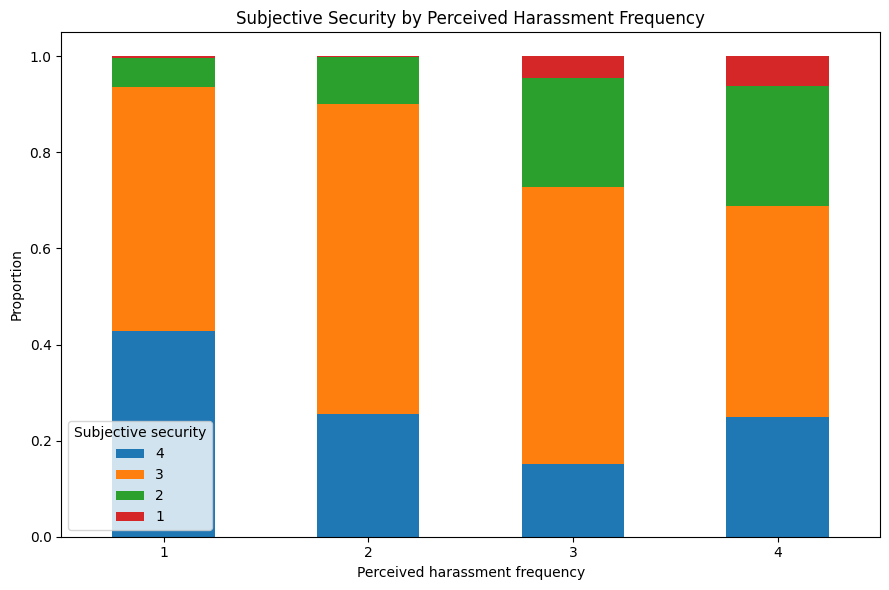

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

# Cross-tabulation: harassment frequency × subjective security
stacked = pd.crosstab(
    sg["harassment_r"],
    sg["security_r"],
    normalize="index"
)

stacked = stacked.reindex(index=[1, 2, 3, 4], columns=[4, 3, 2, 1])

ax = stacked.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

ax.set_title("Subjective Security by Perceived Harassment Frequency")
ax.set_xlabel("Perceived harassment frequency")
ax.set_ylabel("Proportion")
ax.set_xticklabels(["1", "2", "3", "4"], rotation=0)
ax.legend(title="Subjective security")

plt.tight_layout()
plt.show()







## Heatmap

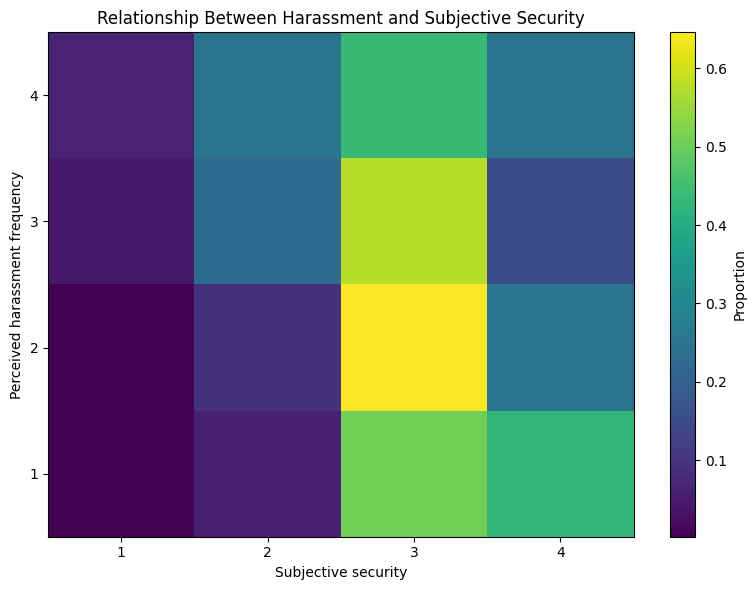

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# Proportion of subjective security categories within each harassment category
heatmap_data = pd.crosstab(sg["harassment_r"], sg["security_r"], normalize="index")

heatmap_data = heatmap_data.reindex(index=[4, 3, 2, 1], columns=[1, 2, 3, 4])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(heatmap_data.values, aspect="auto")

ax.set_xticks(np.arange(4))
ax.set_xticklabels(["1", "2", "3", "4"])
ax.set_yticks(np.arange(4))
ax.set_yticklabels(["4", "3", "2", "1"])

ax.set_xlabel("Subjective security")
ax.set_ylabel("Perceived harassment frequency")
ax.set_title("Relationship Between Harassment and Subjective Security")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Proportion")

plt.tight_layout()
plt.show()

## Gender Interaction Graph

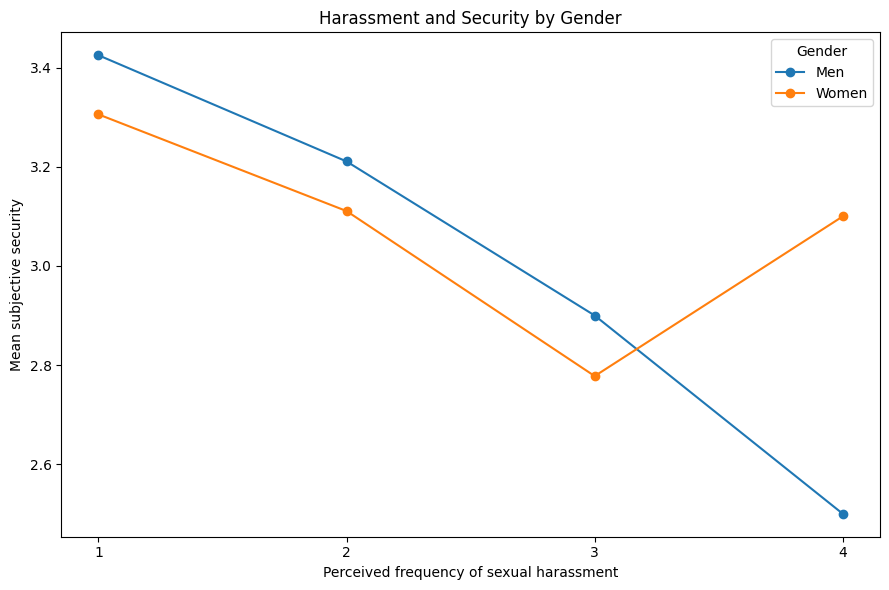

In [94]:
# Mean subjective security by harassment frequency and gender
plot_data = (
    sg.dropna(subset=["harassment_r", "security_r", "gender_bi"])
      .groupby(["harassment_r", "gender_bi"])["security_r"]
      .mean()
      .reset_index()
)

men = plot_data[plot_data["gender_bi"] == 0]
women = plot_data[plot_data["gender_bi"] == 1]

plt.figure(figsize=(9, 6))

plt.plot(
    men["harassment_r"],
    men["security_r"],
    marker="o",
    label="Men"
)

plt.plot(
    women["harassment_r"],
    women["security_r"],
    marker="o",
    label="Women"
)

plt.title("Harassment and Security by Gender")
plt.xlabel("Perceived frequency of sexual harassment")
plt.ylabel("Mean subjective security")

plt.xticks([1, 2, 3, 4])
plt.legend(title="Gender")

plt.tight_layout()
plt.show()


In [95]:
pd.crosstab(sg["harassment_r"], sg["gender_bi"], margins=True)


gender_bi,0,1,All
harassment_r,,,
1.0,680,773,1453
2.0,204,262,466
3.0,30,36,66
4.0,6,10,16
All,920,1081,2001


**Note:** The number of respondents reporting the highest level of perceived harassment frequency (category 4) is small (n = 16; 6 men and 10 women). Therefore, the gender-specific mean subjective security at this level should be interpreted with caution.